In [66]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from ast import literal_eval

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:literal_eval(x) if pd.notna(x) else x)

In [45]:
df_DA = df[df['job_title_short']=='Data Analyst'].copy()
df_DA['job_posted_month'] = df_DA['job_posted_date'].dt.month
df_DA = df_DA.explode('job_skills')
df_DA_pivot = df_DA.pivot_table(index='job_posted_month',columns='job_skills',aggfunc='size',fill_value=0)

In [46]:
df_DA_pivot.loc['total_job_count'] = df_DA_pivot.sum()
df_DAseries = df_DA_pivot[df_DA_pivot.loc['total_job_count'].sort_values(ascending=False).index]

In [47]:
df_DAseries = df_DAseries.iloc[:,:5].drop('total_job_count')

df_DAseries

job_skills,sql,excel,python,tableau,power bi
job_posted_month,,,,,
1,11336,8170,6606,5596,4285
2,7947,5772,4751,3936,3307
3,7868,5675,4741,4051,3176
4,7553,5496,4557,3776,3106
5,6617,4773,4070,3245,2695
6,7584,5724,4707,3812,3275
7,7687,5513,4831,3928,3350
8,8823,6482,5576,4533,3859
9,6829,4886,4229,3446,3118


In [56]:
df_DAseries = df_DAseries.reset_index()
df_DAseries['job_posted_month_name']=pd.to_datetime(
    df_DAseries['job_posted_month'],format='%m').dt.strftime('%b')
df_DAseries = df_DAseries.set_index('job_posted_month_name')
df_DAseries = df_DAseries.drop(columns='job_posted_month')

df_DAseries

job_skills,sql,excel,python,tableau,power bi
job_posted_month_name,,,,,
Jan,11336,8170,6606,5596,4285
Feb,7947,5772,4751,3936,3307
Mar,7868,5675,4741,4051,3176
Apr,7553,5496,4557,3776,3106
May,6617,4773,4070,3245,2695
Jun,7584,5724,4707,3812,3275
Jul,7687,5513,4831,3928,3350
Aug,8823,6482,5576,4533,3859
Sep,6829,4886,4229,3446,3118


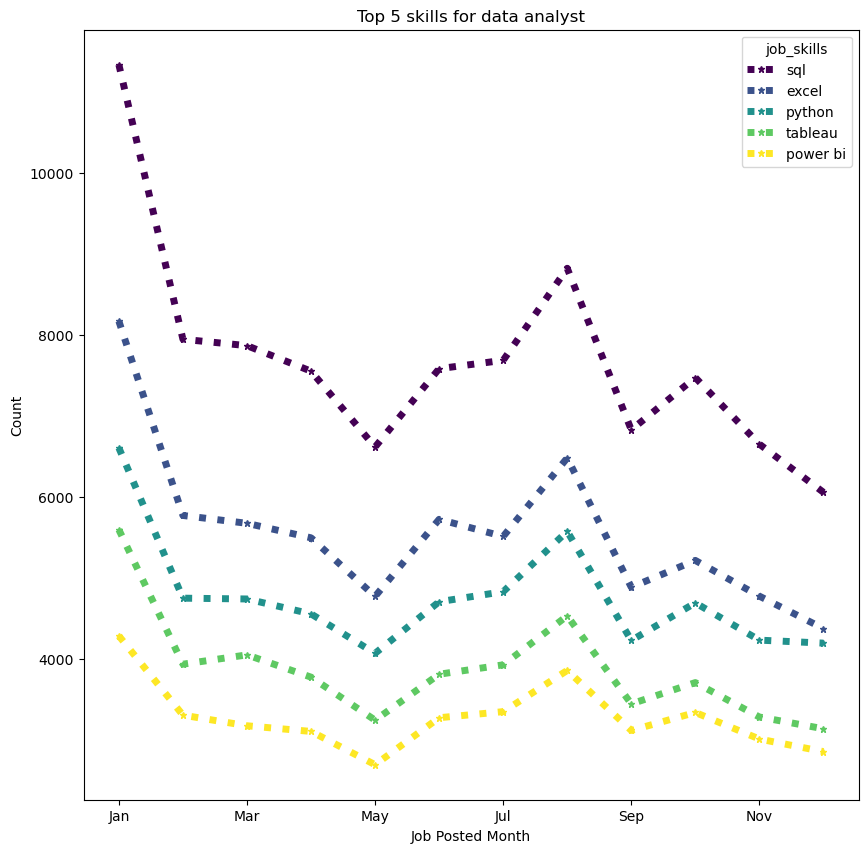

In [57]:
df_DAseries.plot(kind='line',
                 linewidth=5,
                 linestyle=':',  #options':','-','--','-.'
                 colormap='viridis',  #options'viridis','plasma','inferno','magma','cividis'
                 marker='*',     #options'*','+','o','x','s',',','.','1','2','3','4',...
                 markersize=5,
                 figsize=(10,10)
                 )
plt.title(f'Top 5 skills for data analyst')
plt.xlabel('Job Posted Month')
plt.ylabel('Count')
plt.show()

In [65]:
count=10
df_DA_scatter =  df_DA.groupby('job_skills').agg(
    job_count = ('job_skills','count'),
    median_salary = ('salary_year_avg','median')
).sort_values(by='job_count',ascending=False).head(count)
df_DA_scatter

,job_count,median_salary
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


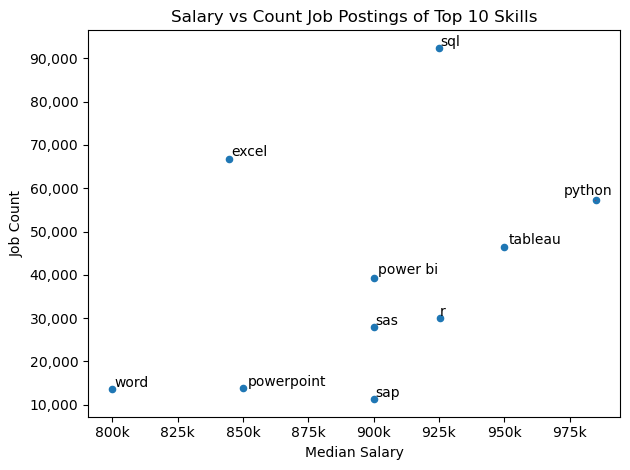

In [82]:
from adjustText import adjust_text

df_DA_scatter.plot(kind='scatter',x='median_salary',y='job_count')
plt.title('Salary vs Count Job Postings of Top 10 Skills')
plt.xlabel('Median Salary')
plt.ylabel('Job Count')

texts=[]
for i,title in enumerate(df_DA_scatter.index):
    texts.append(plt.text(df_DA_scatter['median_salary'].iloc[i],df_DA_scatter['job_count'].iloc[i],title))
adjust_text(texts,arrowprops=dict(arrowstyle='-',color='r',lw=0.5))

ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'{int(y/100)}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x):,}'))
plt.tight_layout()
plt.show()